# Google Trends Data: Analyzing the Lipstick Effect through Search Intensity

Bailey Carpenter

ECO 590

Spring 2026

# Motivation
Social media has created a vaccuum where people want to be seen and viewed as luxury even if they cannot afford luxury goods. This can be seen in many ways, be it buying replicas of luxury products through online Chinese blackmarkets or foregoing your grocery money in order to purchase that Balenciaga City bag every girl on TikTok has. But how is this seen for the average consumer who does not have the means or desire to go through these extreme measures? Coined by Estee Lauder's chairman Leonard Lauder in 2001, the "lipstick effect" poses the theory that in times of economic downturn or recession, the sales for smaller luxury items like makeup or skincare rise as a way for people going through hardtimes to splurge in the luxury market outside of the clothes or accessories they are now priced out of. What I am interested in analyzing is how this effect can be seen in today's world, 25 years after this theory was first established. 

# Research Question: 
## Does the search intensity for luxury cosmetics coincide with decreased wages? 

# Parts 1 & 2 - Using APIs for Google Trends Data and Cleaning Data

I used Pytrends for my API as the official Google Trends API is still in its' beta testing phase, however pytrends is a trusted and well documented resource for pulling this type of data. I compiled my list of search terms by researching multiple top lists of luxury cosmetics, choosing from both makeup brands as well as skincare brands. This stems from the increase in interest for skincare that started in around 2020 during the COVID-19 Pandemic, with the skincare market generating about 63.3 billion US Dollars in 2023 alone. 

# Pulling Data from Pytrends

Google Trends scales each term from 0-100, so in order to present comparable data I used "Chanel Beauty" as an anchor variable to keep each term scaled to one another. A list of search terms was created and stored in a list, which was then divided into batches due to Google Trends' limits on simultaneous pulling. 

For each batch, the Google Trends API was queried with the "***build payload***" function, using the parameters "***timeframe***" and "***geo***" to restrict results to just 2021-2025 in the United States. The column "isPartial" was removed as it provides incomplete data that is not relevant to this analysis. To prevent code 429, the "***time.sleep***" function was used to put random pauses between each pull request. 

Rescaling the batches was necessary to keep the data comparable, and I used the mean value of the anchor term in the first batch as the baseline normalization factor. For each batch thereafter, a scaling batch was calculated and multiplied to produce comparable measures across all search terms. These were then merged into a single dataframe and the duplicate columns were dropped. For ease of merging with my CSV dataset, I converted the index into a datetime object, generating year and quarter in order to align with my macroeconomic data. 

In [5]:
!pip install pytrends #install required programs
!pip install requests
import pandas as pd #importing pandas
import time
import random
from pytrends.request import TrendReq #imports the specific API used

pytrends = TrendReq(hl='en-US', tz=360) #connects API to Google Trends
terms = ['Tom Ford Beauty', 'Chanel Beauty', 'La Prairie', 'Dior Beauty', 'La Mer', 'Shiseido','Augustinus Bader', 'Caudalie', 'SkinCeuticals', 'YSL Beauty', 'Sisley Paris', 'Lancome', 'Charlotte Tilburry', 'Kiehls', 'Laura Mercier'] #list of search terms
anchor = 'Chanel Beauty' #setting anchor variable
terms_no_anchor = [t for t in terms if t != anchor] #removes anchor from list to prevent duplicates
#creating batches of search terms in groups of 5, including the anchor in each batch for normalization purposes
batches = [
    [anchor] + terms_no_anchor[i:i+4]
    for i in range(0, len(terms_no_anchor), 4)]
all_batches = [] #empty list to store all dataframe results
#loops through each batch of search terms
for batch in batches:
    #begins try block in the case the API request fails
    try:
        print("Pulling:", batch)
        pytrends.build_payload(
            batch,
            timeframe='2022-01-01 2025-12-31',
            geo='US')
        df = pytrends.interest_over_time()
        df = df.drop(columns=['isPartial'], errors='ignore')
        all_batches.append(df)
        time.sleep(random.randint(20, 45))
    #catches errors if request fails
    except Exception as e:
        print("Error:", e)
        time.sleep(90) #pauses before continuing
#empty list for normalized dataframes       
scaled_batches = []
base_anchor_mean = all_batches[0][anchor].mean() #calculates average value of anchor term in first batch to be used as baseline
#loops through each dataframe batch
for df in all_batches:
    batch_anchor_mean = df[anchor].mean()
    scale_factor = base_anchor_mean/batch_anchor_mean
    df_scaled = df*scale_factor
    scaled_batches.append(df_scaled)
final_df = pd.concat(scaled_batches, axis=1) #merges all scaled batches into one data frame by columns using the shared date index
final_df.index = pd.to_datetime(final_df.index) #since time is the index in this dataframe, i needed to create variables for the year and quarter since that is how it is given from BLS
final_df["year"] = df.index.year #creates year variable
final_df["quarter"] = "Q" + df.index.quarter.astype(str) #separates the weeks and months into quarters based on the parameters from BLS
final_df = final_df.loc[:, ~final_df.columns.duplicated()] #removes duplicate columns generated during concentration

Pulling: ['Chanel Beauty', 'Tom Ford Beauty', 'La Prairie', 'Dior Beauty', 'La Mer']
Pulling: ['Chanel Beauty', 'Shiseido', 'Augustinus Bader', 'Caudalie', 'SkinCeuticals']
Pulling: ['Chanel Beauty', 'YSL Beauty', 'Sisley Paris', 'Lancome', 'Charlotte Tilburry']
Pulling: ['Chanel Beauty', 'Kiehls', 'Laura Mercier']


,Chanel Beauty,Tom Ford Beauty,La Prairie,Dior Beauty,La Mer,Shiseido,Augustinus Bader,Caudalie,SkinCeuticals,YSL Beauty,Sisley Paris,Lancome,Charlotte Tilburry,Kiehls,Laura Mercier
date,,,,,,,,,,,,,,,
2021-12-26,8.0,3.0,18.0,13.0,66.0,50.728845,9.437925,22.415071,55.447807,7.180451,0.0,718.045113,0.0,54.344205,62.297016
2022-01-02,10.0,3.0,19.0,15.0,73.0,46.009883,8.258184,21.235330,60.166770,7.180451,0.0,509.812030,0.0,50.367800,50.367800
2022-01-09,8.0,2.0,19.0,13.0,68.0,47.189623,9.437925,21.235330,63.705991,7.180451,0.0,567.255639,0.0,46.391395,49.042332
2022-01-16,9.0,2.0,16.0,12.0,62.0,43.650401,7.078443,20.055590,57.807288,7.180451,0.0,473.909774,0.0,42.414990,46.391395
2022-01-23,8.0,2.0,18.0,12.0,57.0,47.189623,8.258184,27.134033,63.705991,7.180451,0.0,430.827068,0.0,43.740458,47.716863


# Macroeconomic Data

For my economic data, I utilized the Wage and Salaries of Civillian Workers dataset from the Bureau of Labor Statistics. This data is presented in a 12-month percent change in the growth of wages over each quarter. Using Pandas, I was able to import the data from the CSV file and clean it so the time variables were the same with my API data for ease of merging. 

# Luxury Index

For my newly created variable, I chose to combine the luxury cosmetics and skincare means into a single variable to represent the average interest in the luxury personal care market. 

In [10]:
labor = pd.read_csv('/Users/baileycarpenter/Downloads/file.csv') #importing labor statistics on wages and salaries
df.index = pd.to_datetime(df.index) #since time is the index in this dataframe, i needed to create variables for the year and quarter since that is how it is given from BLS
df["year"] = df.index.year #creates year variable
df["quarter"] = "Q" + df.index.quarter.astype(str) #separates the weeks and months into quarters based on the parameters from BLS
labor = labor.drop ('Series ID', axis=1) #removes unnecessary variable
labor['quarter'] = labor['Period'].str.replace('Q0', 'Q') #attempt to match the variables for data merging, shown below did not work
labor['year'] = labor['Year']

merged = pd.merge(final_df, labor, on=['year', 'quarter'], how="inner") #merging the data 
merged = merged.drop ('year', axis=1) #dropping the redundant variables
merged = merged.drop ('quarter', axis=1)
merged = merged.drop ('Label', axis=1) #label is unneded as it provides the same information as the variables year and period
merged['luxury index'] = merged[['Tom Ford Beauty', 'Chanel Beauty', 'La Prairie', 'Dior Beauty', 'La Mer', 'Shiseido','Augustinus Bader', 'Caudalie', 'SkinCeuticals', 'YSL Beauty', 'Sisley Paris', 'Lancome', 'Charlotte Tilburry', 'Kiehls', 'Laura Mercier']].mean(axis = 1) #creating an index for the average interest in luxury cosmetics
merged

,Chanel Beauty,Tom Ford Beauty,La Prairie,Dior Beauty,La Mer,Shiseido,Augustinus Bader,Caudalie,SkinCeuticals,YSL Beauty,Sisley Paris,Lancome,Charlotte Tilburry,Kiehls,Laura Mercier,Year,Period,Value,luxury index
0,10.0,3.0,19.0,15.0,73.0,46.009883,8.258184,21.235330,60.166770,7.180451,0.000000,509.812030,0.0,50.367800,50.367800,2022,Q01,4.7,58.226550
1,8.0,2.0,19.0,13.0,68.0,47.189623,9.437925,21.235330,63.705991,7.180451,0.000000,567.255639,0.0,46.391395,49.042332,2022,Q01,4.7,61.429246
2,9.0,2.0,16.0,12.0,62.0,43.650401,7.078443,20.055590,57.807288,7.180451,0.000000,473.909774,0.0,42.414990,46.391395,2022,Q01,4.7,53.299222
3,8.0,2.0,18.0,12.0,57.0,47.189623,8.258184,27.134033,63.705991,7.180451,0.000000,430.827068,0.0,43.740458,47.716863,2022,Q01,4.7,51.516845
4,7.0,3.0,18.0,14.0,58.0,44.830142,8.258184,25.954293,61.346510,7.180451,0.000000,516.992481,0.0,46.391395,45.065926,2022,Q01,4.7,57.067959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,15.0,5.0,28.0,30.0,88.0,95.558987,14.156887,60.166770,87.300803,21.541353,7.180451,287.218045,0.0,51.693269,62.297016,2025,Q04,3.3,56.874239
205,17.0,4.0,26.0,26.0,71.0,71.964175,12.977146,44.830142,69.604694,14.360902,7.180451,208.233083,0.0,31.811242,46.391395,2025,Q04,3.3,43.423549
206,17.0,4.0,23.0,25.0,67.0,64.885732,12.977146,43.650401,75.503397,14.360902,7.180451,215.413534,0.0,33.136711,43.740458,2025,Q04,3.3,43.123249
207,23.0,3.0,23.0,30.0,74.0,76.683138,15.336628,49.549104,66.065473,14.360902,7.180451,236.954887,0.0,39.764053,54.344205,2025,Q04,3.3,47.549256


In [11]:
merged.to_csv('/Users/baileycarpenter/Documents/spring 2026/eco 590/final-project-baileycarpener/luxury.csv', index=False)

# Part 3: Graphs

### Graph 1 - Luxury Interest over Time

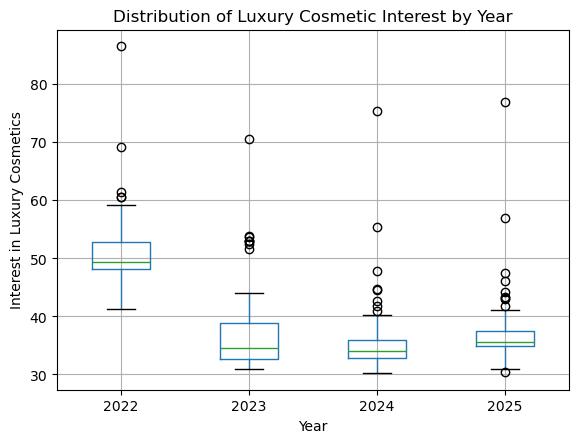

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import ratelim
import tenacity
import requests

df = pd.read_csv('/Users/baileycarpenter/Documents/spring 2026/eco 590/final-project-baileycarpener/luxury.csv')

df.boxplot(column='luxury index', by='Year') #creates boxplot showing distribution of data
plt.xlabel('Year') #labels x-axis
plt.ylabel('Interest in Luxury Cosmetics') #labels y-axis
plt.title('Distribution of Luxury Cosmetic Interest by Year') #sets title
plt.suptitle('') #removes automatic boxplot title
plt.savefig('distribution.png', dpi=300)
plt.show() #shows graph

### Interpretation:
The box graph above shows the distribution of luxury cosmetic interest over time. As shown, 2022 represents the highest amount of interest, with substantial drops in 2023 and 2024 before going back up slightly in 2025. Additionally, there are many outliers in the data which is to be expected due to the high levels of variation in the 

### Graph 2 - Correlation Between Wage Growth and Luxury Cosmetics and Skincare

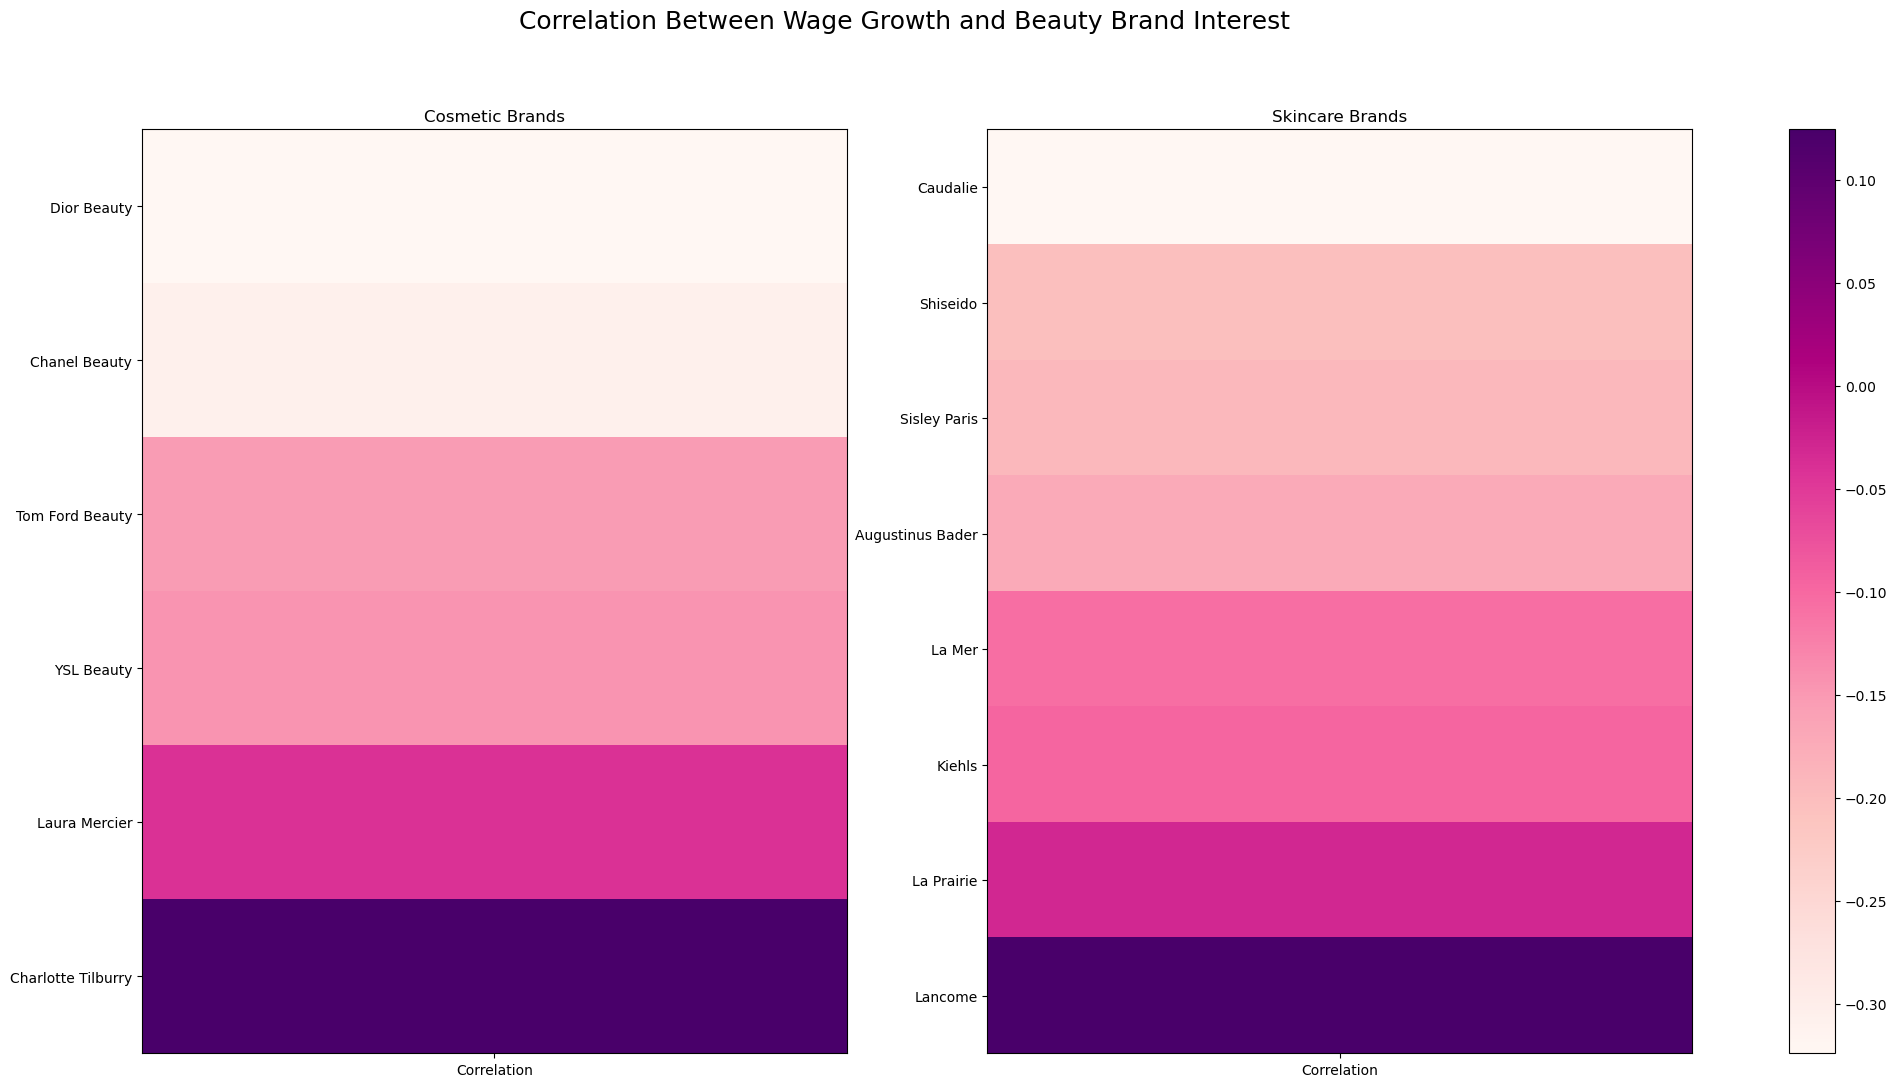

In [59]:
cosmetics = ['Tom Ford Beauty', 'Chanel Beauty', 'Dior Beauty', 'YSL Beauty', 'Laura Mercier', 'Charlotte Tilburry'] #creates list of cosmetic brands
skincare = ['La Prairie', 'La Mer', 'Shiseido', 'Augustinus Bader', 'Caudalie', 'Sisley Paris', 'Lancome', 'Kiehls'] #creates list of skincare brands

coscorrs = df[cosmetics].corrwith(df['Value']) #calculating correlation between cosmetic brands and wage growth
skincorrs = df[skincare].corrwith(df['Value']) #calculating correlation between skincare brands and wage growth

coscorr_df = pd.DataFrame(coscorrs, columns=['Correlation']) #stores new variables in a dataframe
skincorr_df = pd.DataFrame(skincorrs, columns=['Correlation']) #stores new variables in a dataframe
coscorr_df = coscorr_df.sort_values(by='Correlation') #sorts values by their level of correlation
skincorr_df = skincorr_df.sort_values(by='Correlation') #sorts values by their level of correlation

fig, ax = plt.subplots(nrows = 1, ncols= 2, figsize=(25,12)) #creating a figure with 1 row, 2 columns, and sized 25x12
ax1 = plt.subplot(1, 2, 1) #sets first plot in the first axis
im1 = ax1.imshow(coscorr_df, aspect='auto', cmap='RdPu') #plots heatmap in the first axis, with the cmap Red-Purple
ax1.set_title('Cosmetic Brands') #sets title
ax1.set_yticks(range(len(coscorr_df.index))) #sets the ticks to be the size of the index
ax1.set_yticklabels(coscorr_df.index) #labels the yticks to the brand names
ax1.set_xticks([0]) #sets no ticks on the x axis
ax1.set_xticklabels(['Correlation']) #names x axis

ax2 = plt.subplot(1,2,2) #sets second plot in the second axis
im2 = ax2.imshow(skincorr_df, aspect = 'auto', cmap='RdPu') #plots heatmap in the second axis with the same cmap
ax2.set_title('Skincare Brands') #sets title
ax2.set_yticks(range(len(skincorr_df.index))) #sets the ticks to be the size of the index
ax2.set_yticklabels(skincorr_df.index) #sets tick names to the brand names
ax2.set_xticks([0]) #sets no ticks on the x axis
ax2.set_xticklabels(['Correlation']) #names x axis

fig.colorbar(im1, ax=[ax1, ax2]) #sets color bar
plt.suptitle('Correlation Between Wage Growth and Beauty Brand Interest', x = 0.43, fontsize = 18) #plots the title, centered and with a larger font size
plt.savefig('heatmap.png', dpi=300)
plt.show()

### Interpretation: 

The heatmaps above show the level of correlation between wage growth and the different individual cosmetic brands and skincare brands. What we can conclude from this graph is that there are specific brands that show significant correlation with wage growth, being specifically Dior Beauty for cosmetics and Caudalie for skincare. Contrastingly, Charlotte Tilburry and Lancome are shown to have very little to no correlation with wage growth, meaning the relationship is not uniform across all luxury brands.

### Graph 3 - Cosmetic Interest and Wage Growth Over Time

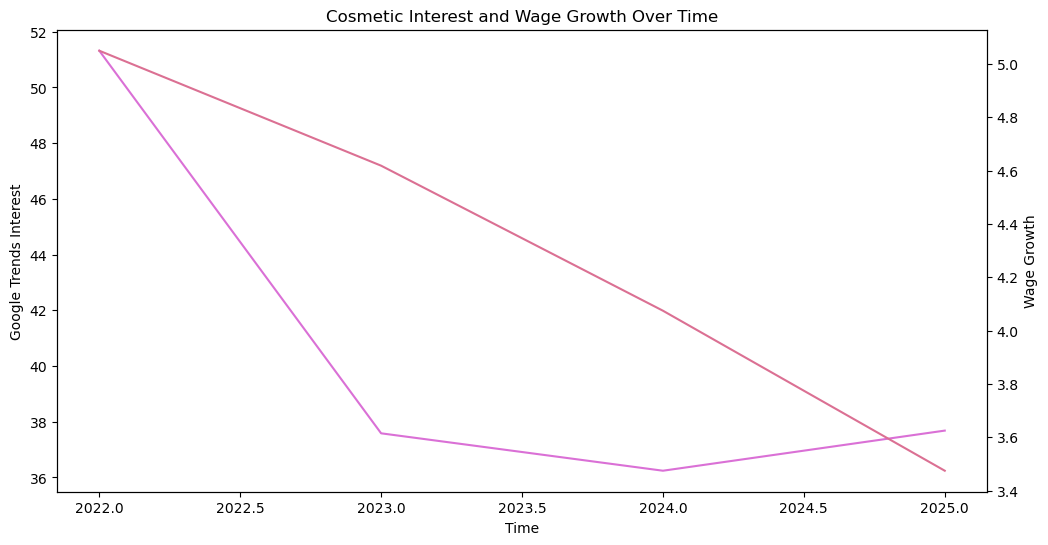

In [60]:
fig, ax1 = plt.subplots(figsize=(12,6)) #sets figure size
yearlydf = df.groupby('Year')[['luxury index','Value']].mean(numeric_only = True).reset_index() #groups data by year and takes the mean of values in luxury index and wage growth

ax1.plot(yearlydf['Year'], yearlydf['luxury index'], color = 'orchid') #plots the first line for luxury index, with the color orchid
ax1.set_ylabel('Google Trends Interest') #sets label for y-axis
ax1.set_xlabel('Time') #sets title for x axis

ax2 = ax1.twinx() #sets the second line on the same x axis with a dual y-axis
ax2.plot(yearlydf['Year'], yearlydf['Value'], color = 'palevioletred') #plots second line for wage growth in the color pale violet red
ax2.set_ylabel('Wage Growth') #labels y axis
ax2.set_xlabel('Time') #labels x axis
plt.title('Cosmetic Interest and Wage Growth Over Time') #sets title of the graph
plt.savefig('dualaxis.png', dpi=300)
plt.show()

### Interpretation:

The dual axis line graph above shows interest in luxury cosmetics on wage growth over time. What we see in this graph is that interest in luxury cosmetics dips significantly in 2023 and stays low through the year before begininning to increase again in 2025. Wage growth is shown to have much more consistent decline over the years, coinciding in late 2024 with the interest line. What we can conlude from this is that the lipstick effect may not be in play in the timeframe selected, and rather may be seen in more recent years instead.